# Event Hit Animation

Generates an animated GIF of PMT hits arriving over time.
- Uses quantile-transformed time to spread hits evenly across frames
- Hits with PE <= 1 are excluded from the quantile calculation (but still displayed)
- Cumulative display: once a pixel turns on, it stays on
- A time progress bar on the left shows real (physical) time progression

In [1]:
import torch

import sys
sys.path.append('..')

from tools.geometry import generate_detector, load_detector_geom
from tools.utils import load_single_event, save_single_event, generate_random_params, print_particle_params, sparse_to_full
from tools.losses import WC_loss
from tools.simulation import setup_event_simulator
from tools.generate import read_photon_data_from_photonsim
from tools.detector_params import ParticleParams, load_detector_params

import jax
import jax.numpy as jnp
import time

from jax import jit
from pathlib import Path

from matplotlib import pyplot as plt
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10

import numpy as np
from functools import partial
import pickle
from tqdm import tqdm
from jax import grad, jit, vmap, value_and_grad
import uproot

from matplotlib.collections import EllipseCollection
from scipy.spatial.distance import pdist
from mpl_toolkits.axes_grid1 import make_axes_locatable
import imageio

## Setup detector and load event

In [2]:
default_json_filename = '../config/SK_geom_config.json'
data_file = '../data/water/muon/muon_gun_1050_MeV_100_events_fixed_energy.root'

PHYSICS_CONFIG = '../config/SK_physics_config.json'
detector_params = load_detector_params(PHYSICS_CONFIG)

detector = generate_detector(default_json_filename)
detector_points = jnp.array(detector.all_points)
detector_radius = detector.S_radius
NUM_DETECTORS = len(detector_points)
Nphot = 1_000_000

K = 20

data_simulator = setup_event_simulator(default_json_filename, Nphot, temperature=0.0, K=K,
                                      is_data=True, is_calibration=False, physics_config=PHYSICS_CONFIG, default_detector_params=True)

print(f"Number of detectors: {NUM_DETECTORS}")

# Load ROOT file information
with uproot.open(data_file) as file:
    tree = file['OpticalPhotons']
    n_entries = tree.num_entries
print(f"ROOT file has {n_entries} entries")

Number of detectors: 10764
ROOT file has 100 entries


In [19]:
# Generate random entry index and event parameters
key = jax.random.PRNGKey(719007)
entry_key = jax.random.PRNGKey(12345)

# Select entry from ROOT file
entry_idx = 5
print(f"Loading entry {entry_idx} from ROOT file")

# Load photon data from ROOT file
photon_data = read_photon_data_from_photonsim(data_file, entry_idx)
photon_data['N'] = len(photon_data['photon_origins'])

true_position = jnp.array([-10., 0., 0.])
true_direction = jnp.array([1., 0., 0.])
true_energy = photon_data['energy']

true_track = ParticleParams.from_cartesian(
    energy=true_energy, position=true_position,
    direction=true_direction, t0=0.0
)

original_direction = jnp.array([0.0, 0.0, 1.0])
true_direction_norm = true_direction / (jnp.linalg.norm(true_direction) + 1e-8)

rotation_axis = jnp.cross(original_direction, true_direction_norm)
axis_norm = jnp.linalg.norm(rotation_axis)
rotation_axis = jnp.where(
    axis_norm < 1e-6,
    jnp.array([1.0, 2.0, 3.0]),
    rotation_axis / (axis_norm + 1e-8)
)
rotation_angle = jnp.arccos(jnp.clip(
    jnp.dot(original_direction, true_direction_norm), -1.0, 1.0
))

photon_data['rotation_axis'] = rotation_axis
photon_data['rotation_angle'] = rotation_angle
photon_data['apply_rotation'] = jnp.array(True)
photon_data['apply_translation'] = jnp.array(True)
photon_data['translation_vector'] = true_position

true_data = jax.lax.stop_gradient(data_simulator(true_track, key, photon_data))

print("True parameters:")
print(f"  Energy: {true_energy:.2f} MeV")
print(f"  Position: [{true_position[0]:.2f}, {true_position[1]:.2f}, {true_position[2]:.2f}] m")
print(f"  Direction: [{true_direction[0]:.3f}, {true_direction[1]:.3f}, {true_direction[2]:.3f}]")
print(f"  Photon data: {photon_data['N']} photons")

Loading entry 5 from ROOT file
True parameters:
  Energy: 1050.00 MeV
  Position: [-10.00, 0.00, 0.00] m
  Direction: [1.000, 0.000, 0.000]
  Photon data: 351939 photons


## Save and load event, convert to dense arrays

In [20]:
event_location = 'output/data_like_event.h5'

event_dir = Path('output')
event_dir.mkdir(parents=True, exist_ok=True)
figures_dir = Path('figures')
figures_dir.mkdir(parents=True, exist_ok=True)

save_single_event(true_data, true_track, detector_params, filename=event_location, calibration_mode=False)

loaded_trk_params, loaded_detector_params, loaded_indices, loaded_charges, loaded_times = load_single_event(event_location, NUM_DETECTORS, calibration_mode=False)
print_particle_params(loaded_trk_params)

# Convert sparse to dense
all_charges = np.array(sparse_to_full(loaded_indices, loaded_charges, NUM_DETECTORS))
all_times = np.array(sparse_to_full(loaded_indices, loaded_times, NUM_DETECTORS))

print(f"Sensors hit (charge > 0): {np.sum(all_charges > 0)}")
print(f"Time range: {all_times[all_times > 0].min():.1f} - {all_times[all_times > 0].max():.1f} ns")
print(f"Charge range: {all_charges[all_charges > 0].min():.2f} - {all_charges[all_charges > 0].max():.2f} PE")

Particle Parameters:
  Energy: 1050.00 MeV
  Position: [-10.00, 0.00, 0.00] m
  Direction angles: theta=1.57 rad, phi=0.00 rad
  Direction vector: [1.00, 0.00, -0.00]
  t0: 0.0000
Sensors hit (charge > 0): 3688
Time range: 37.2 - 513.3 ns
Charge range: 0.96 - 17.47 PE


## Compute quantile transform on hit times

We compute quantiles using only hits with PE > 1 (to avoid noise skewing the mapping), then apply to all hits.

In [21]:
PE_THRESHOLD = 1  # Exclude PE <= 1 from quantile calculation

hit_mask = all_charges > 0  # All sensors that were hit
significant_mask = all_charges > PE_THRESHOLD  # Hits used for quantile calc

# Times of significant hits (for building the quantile mapping)
significant_times = all_times[significant_mask]
significant_times_sorted = np.sort(significant_times)

# Compute quantile for every hit sensor using the significant-hit distribution
# searchsorted gives the rank of each time in the sorted significant times
quantiles = np.zeros(len(all_times))
quantiles[hit_mask] = np.searchsorted(significant_times_sorted, all_times[hit_mask]) / len(significant_times_sorted)
quantiles = np.clip(quantiles, 0, 1)

print(f"Significant hits (PE > {PE_THRESHOLD}): {np.sum(significant_mask)}")
print(f"Total hits: {np.sum(hit_mask)}")
print(f"Quantile range for hit sensors: {quantiles[hit_mask].min():.3f} - {quantiles[hit_mask].max():.3f}")

Significant hits (PE > 1): 2502
Total hits: 3688
Quantile range for hit sensors: 0.000 - 1.000


## Detector display with time progress bar

In [22]:
def calculate_min_distance(positions):
    distances = pdist(positions)
    return np.min(distances) if len(distances) > 0 else 1.0


def setup_detector_geometry(json_filename):
    """Pre-compute detector layout positions (barrel unrolled + caps).
    Returns transformed x, y, sensor_cases, circle_diameter, and axis limits."""
    detector = generate_detector(json_filename)
    detector_type, radius, height, n_sensors, sensor_radius = load_detector_geom(json_filename)

    if detector_type != 'cylinder':
        raise ValueError(f"This visualization is designed for cylinders, got {detector_type}")

    sensor_positions = np.array(detector.all_points)
    sensor_cases = np.array([detector.ID_to_case[i] for i in range(len(detector.all_points))])
    n_sensors = len(sensor_positions)

    caps_offset = 1.05 * height / 2 + radius

    x = np.zeros(n_sensors)
    y = np.zeros(n_sensors)

    # Barrel
    barrel_mask = sensor_cases == 0
    theta = np.arctan2(sensor_positions[barrel_mask, 1], sensor_positions[barrel_mask, 0])
    theta = (theta + np.pi * 3 / 2) % (2 * np.pi) / 2
    x[barrel_mask] = theta * radius * 2
    y[barrel_mask] = sensor_positions[barrel_mask, 2]

    # Top cap
    top_mask = sensor_cases == 1
    x[top_mask] = sensor_positions[top_mask, 0] + np.pi * radius
    y[top_mask] = (caps_offset + sensor_positions[top_mask, 1])

    # Bottom cap
    bottom_mask = sensor_cases == 2
    x[bottom_mask] = sensor_positions[bottom_mask, 0] + np.pi * radius
    y[bottom_mask] = (-caps_offset - sensor_positions[bottom_mask, 1])

    transformed_positions = np.column_stack((x, y))
    circle_diameter = calculate_min_distance(transformed_positions)

    padding = circle_diameter
    x_min, x_max = np.min(x) - padding, np.max(x) + padding
    y_min, y_max = np.min(y) - padding, np.max(y) + padding

    return {
        'positions': transformed_positions,
        'circle_diameter': circle_diameter,
        'xlim': (x_min, x_max),
        'ylim': (y_min, y_max),
        'n_sensors': n_sensors,
    }


geom = setup_detector_geometry(default_json_filename)
print(f"Geometry ready: {geom['n_sensors']} sensors, circle diameter = {geom['circle_diameter']:.4f}")

Geometry ready: 10764 sensors, circle diameter = 0.7127


In [23]:
def render_frame(geom, all_charges, all_times, quantiles, q_threshold,
                 time_min, time_max, charge_vmin, charge_vmax):
    """
    Render a single animation frame.

    Sensors with quantile <= q_threshold are shown with their charge color.
    Sensors not yet hit are shown in light gray.

    Returns a matplotlib figure.
    """
    positions = geom['positions']
    cd = geom['circle_diameter']
    x_min, x_max = geom['xlim']
    y_min, y_max = geom['ylim']
    x_range = x_max - x_min
    y_range = y_max - y_min

    # Figure dimensions: add space on the left for the time bar
    bar_width_frac = 0.04
    fig_width = 8
    fig_height = fig_width * (y_range / x_range)

    fig, (ax_bar, ax) = plt.subplots(
        1, 2, figsize=(fig_width + 0.8, fig_height),
        gridspec_kw={'width_ratios': [bar_width_frac, 1], 'wspace': 0.02},
        facecolor='white'
    )

    # --- Time progress bar (left) ---
    # Map current quantile threshold to real time
    # Find the real time corresponding to this quantile
    hit_mask = all_charges > 0
    hit_times = all_times[hit_mask]
    hit_quantiles = quantiles[hit_mask]

    if q_threshold > 0 and len(hit_times) > 0:
        # Current time = max real time among hits that have appeared so far
        arrived = hit_quantiles <= q_threshold
        if np.any(arrived):
            current_time = np.max(hit_times[arrived])
        else:
            current_time = time_min
    else:
        current_time = time_min

    # Draw the progress bar
    time_frac = np.clip((current_time - time_min) / (time_max - time_min + 1e-8), 0, 1)
    ax_bar.axhspan(0, time_frac, color='#2196F3', alpha=0.8)
    ax_bar.axhspan(time_frac, 1, color='#E0E0E0')
    ax_bar.set_xlim(0, 1)
    ax_bar.set_ylim(0, 1)
    ax_bar.set_xticks([])

    # Time labels
    n_ticks = 5
    tick_positions = np.linspace(0, 1, n_ticks)
    tick_labels = [f"{time_min + t * (time_max - time_min):.0f}" for t in tick_positions]
    ax_bar.set_yticks(tick_positions)
    ax_bar.set_yticklabels(tick_labels, fontsize=7)
    ax_bar.set_ylabel('Time (ns)', fontsize=9)
    ax_bar.tick_params(axis='y', length=2, pad=1)
    for spine in ax_bar.spines.values():
        spine.set_visible(False)

    # --- Detector display (right) ---
    cmap = plt.get_cmap('plasma')
    norm = plt.Normalize(vmin=charge_vmin, vmax=charge_vmax)
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)

    # Determine which sensors have arrived
    arrived_mask = (quantiles <= q_threshold) & (all_charges > 0)

    # Build color array
    gray = np.array([0.9, 0.9, 0.9, 1.0])
    colors = np.tile(gray, (len(all_charges), 1))

    # Set arrived sensors to their charge color
    clipped_charges = np.clip(all_charges[arrived_mask], charge_vmin, charge_vmax)
    colors[arrived_mask] = sm.to_rgba(clipped_charges)

    ells = EllipseCollection(
        widths=cd, heights=cd, angles=0, units='x',
        facecolors=colors, offsets=positions,
        transOffset=ax.transData, edgecolors='none'
    )
    ax.add_collection(ells)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect('equal', adjustable='box')
    ax.axis('off')

    # Colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.1)
    cbar = plt.colorbar(sm, cax=cax)
    cbar.set_label('Photoelectron Count (a.u.)', fontsize=10)

    plt.tight_layout()
    return fig

## Test a single frame

/tmp/ipykernel_1445037/2658972215.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


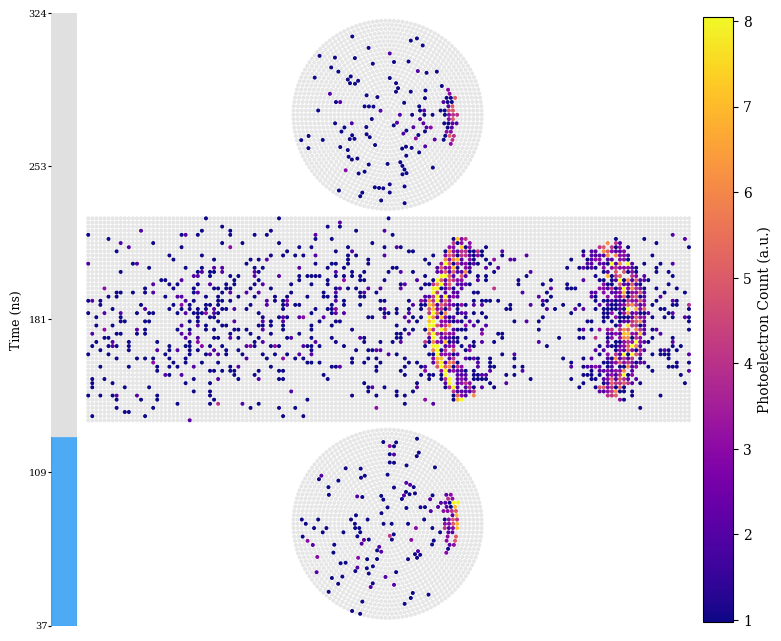

In [24]:
hit_mask = all_charges > 0
positive_charges = all_charges[hit_mask]
time_min = float(all_times[hit_mask].min())
time_max = float(np.percentile(all_times[hit_mask], 99))
charge_vmin = float(np.percentile(positive_charges, 1))
charge_vmax = float(np.percentile(positive_charges, 99))

fig = render_frame(geom, all_charges, all_times, quantiles, q_threshold=0.5,
                   time_min=time_min, time_max=time_max,
                   charge_vmin=charge_vmin, charge_vmax=charge_vmax)
plt.show()
plt.close(fig)

## Generate GIF

In [25]:
# Animation parameters
N_FRAMES = 300
FPS = 50
GIF_PATH = 'figures/event_hit_animation.gif'

# Quantile thresholds for each frame (uniform in quantile space)
q_thresholds = np.linspace(0, 1, N_FRAMES)

frames = []
for i, q in enumerate(tqdm(q_thresholds, desc='Rendering frames')):
    fig = render_frame(geom, all_charges, all_times, quantiles, q_threshold=q,
                       time_min=time_min, time_max=time_max,
                       charge_vmin=charge_vmin, charge_vmax=charge_vmax)

    # Render figure to image array
    fig.canvas.draw()
    image = np.asarray(fig.canvas.buffer_rgba())[..., :3].copy()
    frames.append(image)
    plt.close(fig)

# Add a few extra frames at the end (hold final state)
for _ in range(int(FPS * 1.5)):
    frames.append(frames[-1])

imageio.mimsave(GIF_PATH, frames, fps=FPS, loop=0)
print(f"Saved GIF to {GIF_PATH} ({len(frames)} frames, {FPS} fps, ~{len(frames)/FPS:.1f}s)")

Rendering frames:   0%|          | 0/300 [00:00<?, ?it/s]/tmp/ipykernel_1445037/2658972215.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1445037/2658972215.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
Rendering frames:   1%|          | 2/300 [00:00<00:28, 10.59it/s]/tmp/ipykernel_1445037/2658972215.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1445037/2658972215.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
Rendering frames:   1%|▏         | 4/300 [00:00<00:29, 10.13it/s]/tmp/ipykernel_1445037/2658972215.py:99: UserWarning: This figure includes Axes that are not compatible with tigh

Saved GIF to figures/event_hit_animation.gif (375 frames, 50 fps, ~7.5s)


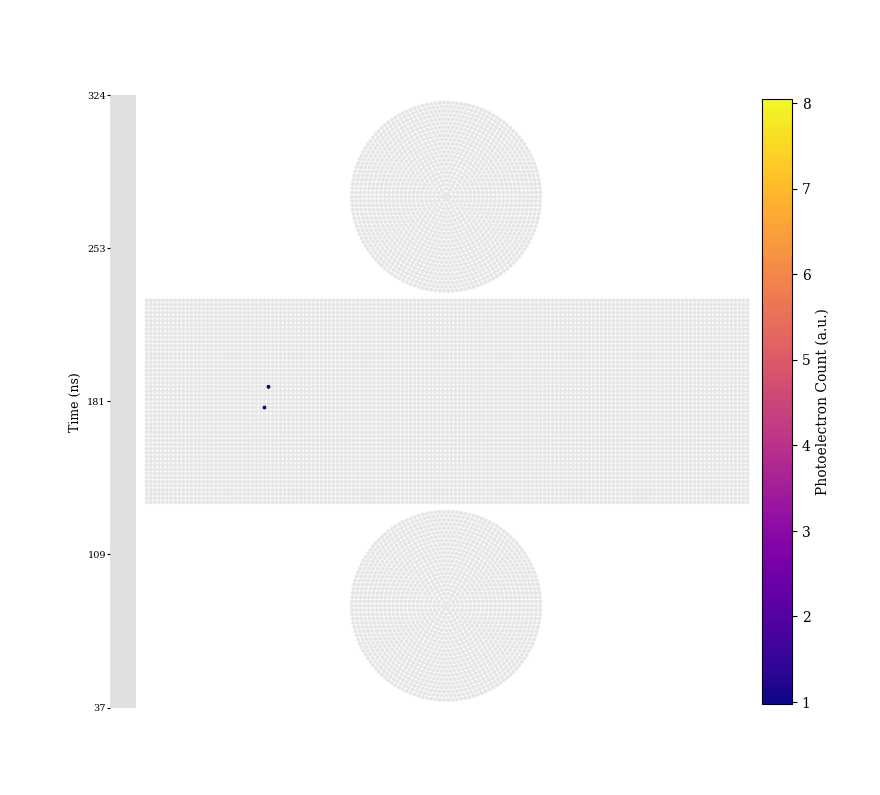

In [27]:
# Display the GIF in the notebook
from IPython.display import Image, display
display(Image(filename=GIF_PATH))